# Análisis Exploratorio de Datos (EDA)
Este notebook analiza el dataset procesado `global_freelancers_processed.csv`.
Las transformaciones y limpieza se realizaron previamente en `02_preparation.ipynb`, aquí nos enfocamos solo en la exploración.


In [6]:
import pandas as pd
from pathlib import Path
import sys
sys.path.insert(0, str(Path.cwd().parent))

from src import plots

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 25)

data_path = Path.cwd().parent / 'data' / 'processed' / 'global_freelancers_processed.csv'
df = pd.read_csv(data_path)
df.head()


,freelancer_ID,name,gender,age,country,language,primary_skill,years_of_experience,hourly_rate (USD),rating,is_active,client_satisfaction
0,FL250001,Ms. Nicole Kidd,f,52.0,Italy,Italian,Blockchain Development,11.0,100,NaN,0,NaN
1,FL250002,Vanessa Garcia,FEMALE,52.0,Australia,English,Mobile Apps,34.0,USD 100,3.3,1,84%
2,FL250003,Juan Nelson,male,53.0,Germany,German,Graphic Design,31.0,50,0.0,N,71%
3,FL250004,Amanda Spencer,F,38.0,Australia,English,Web Development,4.0,$40,1.5,N,90%
4,FL250005,Lynn Curtis DDS,female,53.0,Germany,German,Web Development,27.0,30,4.8,0,83%


## Visión general del dataset
Revisamos las columnas, tipos de datos y estadísticas descriptivas básicas.


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   freelancer_ID        1000 non-null   object 
 1   name                 1000 non-null   object 
 2   gender               1000 non-null   object 
 3   age                  1000 non-null   float64
 4   country              1000 non-null   object 
 5   language             1000 non-null   object 
 6   primary_skill        1000 non-null   object 
 7   years_of_experience  1000 non-null   float64
 8   hourly_rate (USD)    1000 non-null   float64
 9   rating               1000 non-null   float64
 10  is_active            1000 non-null   object 
 11  client_satisfaction  1000 non-null   float64
dtypes: float64(5), object(7)
memory usage: 93.9+ KB


In [9]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
freelancer_ID,1000,1000,FL250001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,1000,992,Mary Brown,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,1000,2,Male,510,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,40.524,11.762218,20.0,31.0,41.0,51.0,60.0
country,1000,21,South Korea,68,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,1000,16,English,215,NaN,NaN,NaN,NaN,NaN,NaN,NaN
primary_skill,1000,10,DevOps,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_of_experience,1000.0,NaN,NaN,NaN,11.221,9.444329,0.0,3.0,9.0,17.0,41.0
hourly_rate (USD),1000.0,NaN,NaN,NaN,51.29,26.259769,20.0,30.0,40.0,75.0,100.0
rating,1000.0,NaN,NaN,NaN,2.5214,1.466572,0.0,1.5,2.6,3.7,5.0


## Valores faltantes
Identificamos cuántos valores faltan en cada columna después de la limpieza inicial.


In [10]:
missing = df.isna().sum()
missing[missing > 0].sort_values(ascending=False)


Series([], dtype: int64)

## Análisis de variables categóricas
Revisamos las principales frecuencias de `country`, `language`, `primary_skill`, `gender` e `is_active`.


In [11]:
categorical_cols = ['country', 'language', 'primary_skill', 'gender', 'is_active']
for col in categorical_cols:
    print(f'--- {col} ---')
    print(df[col].value_counts(dropna=False).head(10))
    print()


--- country ---
country
South Korea       68
Canada            65
Germany           52
Netherlands       51
Australia         51
Mexico            50
United Kingdom    50
United States     49
China             49
Russia            47
Name: count, dtype: int64

--- language ---
language
English       215
Spanish       142
Korean         68
German         52
Dutch          51
Mandarin       49
Russian        47
Indonesian     46
Turkish        45
Hindi          45
Name: count, dtype: int64

--- primary_skill ---
primary_skill
DevOps                    112
UI/UX Design              109
Blockchain Development    105
Web Development           104
Mobile Apps               102
AI                        100
Data Analysis              96
Graphic Design             93
Machine Learning           93
Cybersecurity              86
Name: count, dtype: int64

--- gender ---
gender
Male      510
Female    490
Name: count, dtype: int64

--- is_active ---
is_active
no     554
yes    446
Name: count, dty

## Distribución de edades
Visualizamos cómo se distribuye la edad de los freelancers en el dataset.


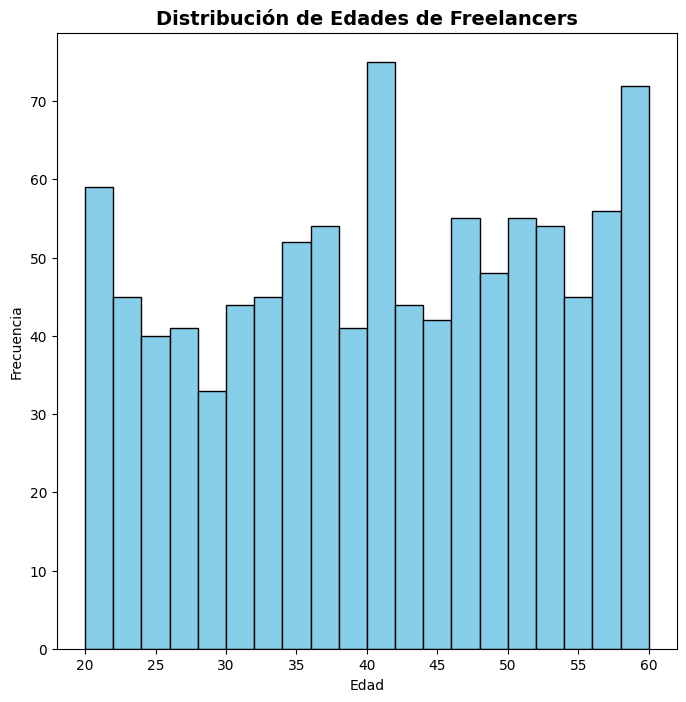

In [12]:
plots.graficar_histograma_edades(df)


## Idiomas más frecuentes
Carga principal de idiomas en la plataforma, agrupando el resto como `Otros`.


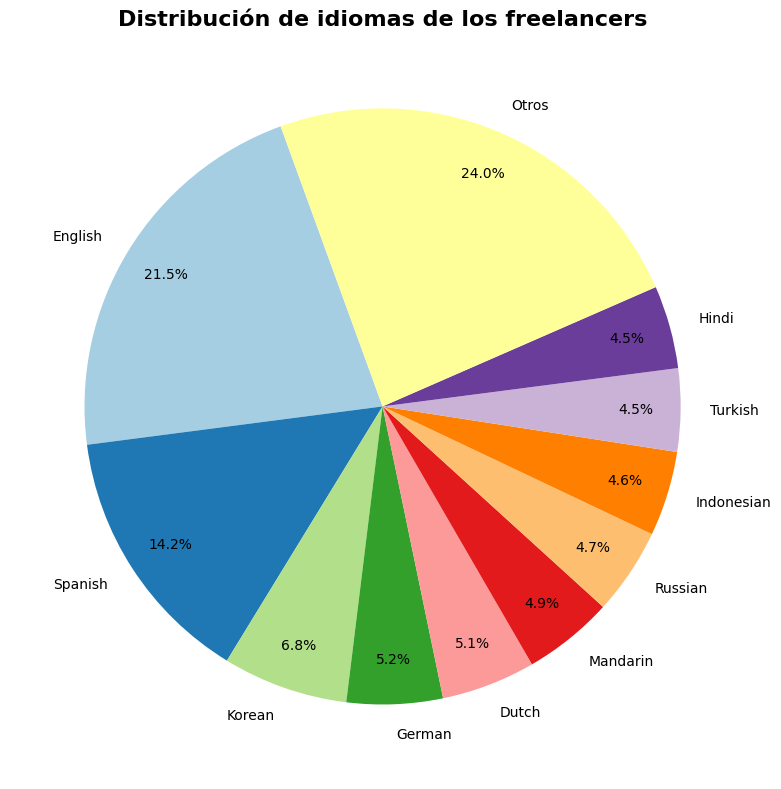

In [13]:
plots.graficar_torta_idioma(df, columna='language', titulo='Distribución de idiomas de los freelancers')


## Matriz de correlación
Evaluamos la relación entre edad, experiencia, tarifa por hora, rating y satisfacción del cliente.


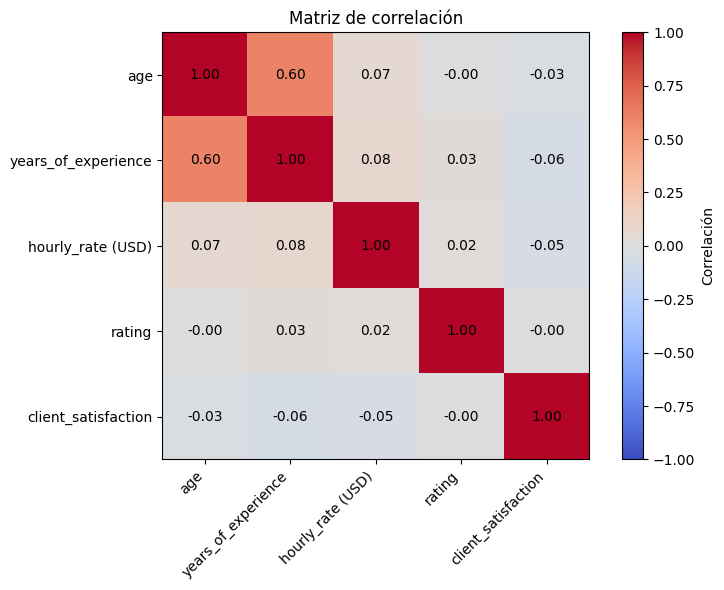

In [15]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(label='Correlación')
plt.xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
plt.yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, f"{corr.iat[i, j]:.2f}", ha='center', va='center', color='black')
plt.title('Matriz de correlación')
plt.tight_layout()
